In [1]:
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from scipy import stats

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)
print("Imports successful.")

Imports successful.


In [2]:
CACHE_DIR = Path("cache")

prices   = pd.read_parquet(CACHE_DIR / "prices.parquet")
pairs_df = pd.read_parquet(CACHE_DIR / "pairs_df.parquet")
sectors  = pd.read_parquet(CACHE_DIR / "sectors.parquet")["sector"]

print(f"prices   : {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"pairs_df : {len(pairs_df)} pairs")
print(f"Date range: {prices.index[0].date()} -> {prices.index[-1].date()}")
pairs_df[["ticker_1","ticker_2","sector","halflife"]].head(10)

prices   : 4132 days x 262 tickers
pairs_df : 25 pairs
Date range: 2010-01-04 -> 2026-06-08


,ticker_1,ticker_2,sector,halflife
0,CPB,CAG,Consumer Staples,95.124425
1,AFL,CB,Financials,95.822810
2,AIZ,ALL,Financials,74.360617
3,AIZ,CINF,Financials,62.112772
4,ALL,CB,Financials,65.312232
5,ALL,CINF,Financials,90.844016
6,AMP,BX,Financials,88.518162
7,BLK,SCHW,Financials,91.193793
8,SCHW,CME,Financials,96.486055
9,A,DHR,Health Care,61.139317


In [3]:
class KalmanFilterHedge:
    """
    Kalman filter for dynamic hedge ratio estimation.
    Identical to 02_modelling.ipynb — reproduced here for self-contained execution.
    """
    def __init__(self, delta: float = 1e-4, R: float = 1e-3):
        self.delta = delta
        self.R     = R
        self.Q     = delta / (1 - delta) * np.eye(2)
        self.state = np.zeros(2)
        self.cov   = np.eye(2) * 1.0

    def update(self, y: float, x: float):
        obs_vec    = np.array([x, 1.0])
        state_pred = self.state
        cov_pred   = self.cov + self.Q
        y_hat      = obs_vec @ state_pred
        innov      = y - y_hat
        S          = obs_vec @ cov_pred @ obs_vec + self.R
        K          = cov_pred @ obs_vec / S
        self.state = state_pred + K * innov
        self.cov   = (np.eye(2) - np.outer(K, obs_vec)) @ cov_pred
        beta       = self.state[0]
        spread     = y - (x * beta + self.state[1])
        return beta, spread, S

In [4]:
# Strategy parameters
ZSCORE_WINDOW    = 63     # Rolling window for z-score (trading days, ~3 months)
ENTRY_THRESHOLD  = 2.0    # Enter trade when |z-score| exceeds this
EXIT_THRESHOLD   = 0.5    # Exit trade when |z-score| falls below this
STOP_LOSS        = 3.0    # Stop loss if |z-score| exceeds this
KALMAN_DELTA     = 1e-4   # Process noise parameter

def generate_signals(s1: pd.Series, s2: pd.Series,
                     zscore_window : int   = ZSCORE_WINDOW,
                     entry         : float = ENTRY_THRESHOLD,
                     exit_thresh   : float = EXIT_THRESHOLD,
                     stop_loss     : float = STOP_LOSS,
                     kalman_delta  : float = KALMAN_DELTA) -> pd.DataFrame:
    """
    Generate trading signals for a single pair using walk-forward Kalman spreads.

    Signal convention:
        +1 = long spread  (buy s1, short s2) — spread is unusually LOW
        -1 = short spread (short s1, buy s2) — spread is unusually HIGH
         0 = flat (no position)

    Parameters
    ----------
    s1, s2        : aligned price series for the pair
    zscore_window : rolling window for z-score normalisation
    entry         : z-score threshold to enter a trade
    exit_thresh   : z-score threshold to exit a trade
    stop_loss     : z-score threshold to stop out

    Returns
    -------
    pd.DataFrame with columns:
        beta, spread, zscore, signal, position
    """
    common = s1.index.intersection(s2.index)
    s1, s2 = s1[common], s2[common]
    n      = len(s1)

    # Initialise Kalman filter
    R  = (s1 - s2).var()
    kf = KalmanFilterHedge(delta=kalman_delta, R=R)

    betas   = np.zeros(n)
    spreads = np.zeros(n)

    # Walk-forward Kalman — strictly sequential, no lookahead
    for i, (y, x) in enumerate(zip(s1.values, s2.values)):
        beta, spread, _ = kf.update(y, x)
        betas[i]        = beta
        spreads[i]      = spread

    spread_series = pd.Series(spreads, index=common)

    # Rolling z-score
    roll_mean = spread_series.rolling(zscore_window, min_periods=zscore_window//2).mean()
    roll_std  = spread_series.rolling(zscore_window, min_periods=zscore_window//2).std()
    zscore    = (spread_series - roll_mean) / roll_std.replace(0, np.nan)

    # Rules applied in priority order: stop loss > exit > entry
    position = np.zeros(n)
    current  = 0   # Current position: +1, -1, or 0

    for i in range(1, n):
        z = zscore.iloc[i]

        if np.isnan(z):
            position[i] = 0
            current     = 0
            continue

        if current != 0:
            # Check stop loss first (highest priority)
            if abs(z) > stop_loss:
                current = 0
            # Check exit
            elif abs(z) < exit_thresh:
                current = 0
            # Otherwise hold
            else:
                position[i] = current
                continue

        # Check for new entry (only if flat after above logic)
        if current == 0:
            if z < -entry:
                current = 1      # Spread too low -> long spread
            elif z > entry:
                current = -1     # Spread too high -> short spread

        position[i] = current

    return pd.DataFrame({
        "beta"    : betas,
        "spread"  : spreads,
        "zscore"  : zscore.values,
        "position": position,
    }, index=common)


# Quick test on CPB/CAG
sig_test = generate_signals(prices["CPB"], prices["CAG"])
print(f"CPB/CAG signal summary:")
print(f"  Total days     : {len(sig_test)}")
print(f"  Days long      : {(sig_test['position'] == 1).sum()}")
print(f"  Days short     : {(sig_test['position'] == -1).sum()}")
print(f"  Days flat      : {(sig_test['position'] == 0).sum()}")
print(f"  % time in mkt  : {(sig_test['position'] != 0).mean()*100:.1f}%")

CPB/CAG signal summary:
  Total days     : 4132
  Days long      : 536
  Days short     : 695
  Days flat      : 2901
  % time in mkt  : 29.8%


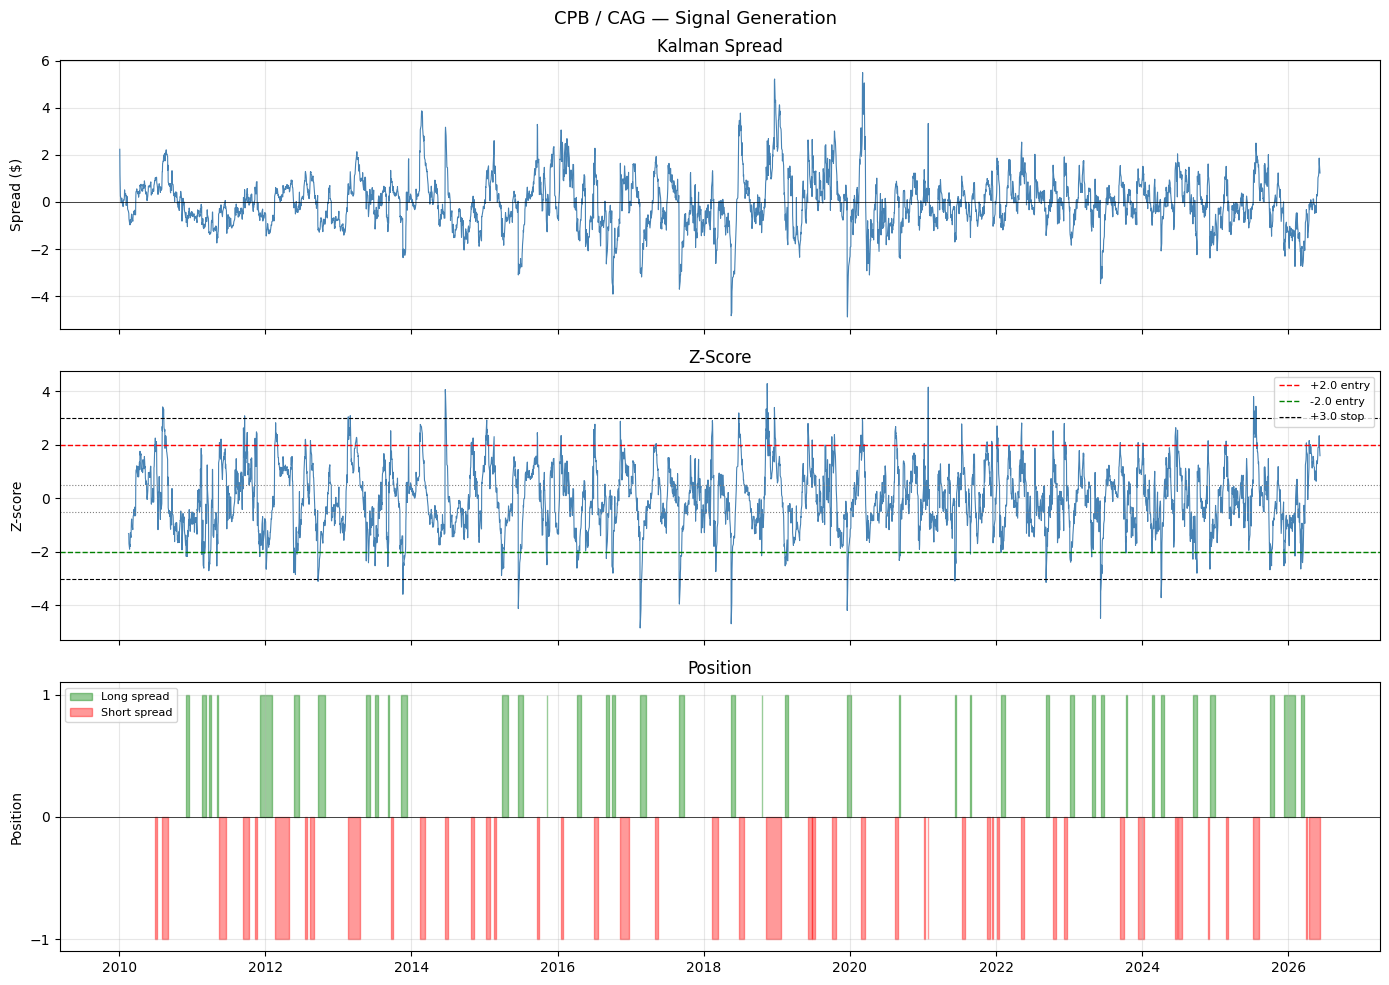

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("CPB / CAG — Signal Generation", fontsize=13)

# Panel 1: Spread
axes[0].plot(sig_test.index, sig_test["spread"], linewidth=0.8, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Kalman Spread")
axes[0].set_ylabel("Spread ($)")
axes[0].grid(True, alpha=0.3)

# Panel 2: Z-score with thresholds
axes[1].plot(sig_test.index, sig_test["zscore"], linewidth=0.8, color="steelblue")
axes[1].axhline( ENTRY_THRESHOLD, color="red",   linestyle="--", linewidth=1, label=f"+{ENTRY_THRESHOLD} entry")
axes[1].axhline(-ENTRY_THRESHOLD, color="green", linestyle="--", linewidth=1, label=f"-{ENTRY_THRESHOLD} entry")
axes[1].axhline( EXIT_THRESHOLD,  color="gray",  linestyle=":",  linewidth=0.8)
axes[1].axhline(-EXIT_THRESHOLD,  color="gray",  linestyle=":",  linewidth=0.8)
axes[1].axhline( STOP_LOSS,       color="black", linestyle="--", linewidth=0.8, label=f"+{STOP_LOSS} stop")
axes[1].axhline(-STOP_LOSS,       color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Z-Score")
axes[1].set_ylabel("Z-score")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(True, alpha=0.3)

# Panel 3: Position
axes[2].fill_between(sig_test.index, sig_test["position"],
                     where=sig_test["position"] > 0, color="green", alpha=0.4, label="Long spread")
axes[2].fill_between(sig_test.index, sig_test["position"],
                     where=sig_test["position"] < 0, color="red",   alpha=0.4, label="Short spread")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_title("Position")
axes[2].set_ylabel("Position")
axes[2].set_yticks([-1, 0, 1])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cache/signals_cpb_cag.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# Walk-forward configuration 
TRAIN_YEARS      = 3      # Initial training window in years
TRADE_MONTHS     = 6      # Trading window in months (roll every 6 months)
TRANSACTION_COST = 0.0005 # 5 basis points per side (10bps round trip)
INITIAL_CAPITAL  = 1_000_000  # $1M starting portfolio

# Set OOS_START to control when trading begins.
#   None  -> starts TRAIN_YEARS after the first data point (default full backtest)
#   "YYYY-MM-DD" -> starts on that date (training uses all data up to that date)
#
# Set OOS_END to control when trading stops.
#   None  -> runs to the last date in the prices data
#   "YYYY-MM-DD" -> stops on that date
#
# Examples:
#   OOS_START, OOS_END = "2020-01-01", "2023-01-01"  # 3-year OOS window
#   OOS_START, OOS_END = "2018-01-01", None           # 2018 onwards
#   OOS_START, OOS_END = None, None                   # full backtest

OOS_START = None
OOS_END   = None

# Position sizing 
# Capital is divided EQUALLY among all pairs found during screening.
# If screening finds 50 pairs: each gets $1M / 50 = $20,000.
# Total exposure can never exceed $1M regardless of how many are active at once.
# (No MAX_PAIR_WEIGHT constant needed -- computed dynamically in run_walk_forward)

# Pair cach
SCREEN_LOOKBACK_DAYS = 1000          # trading days of history per screening month
SCREEN_CACHE_DIR     = "pair_cache"  # directory for Parquet cache files
SCREEN_CACHE_START   = "2013-12-31"  # first month-end to screen

#  Risk management
MAX_DRAWDOWN_PCT = 0.10   # Circuit breaker: cut 50% if DD exceeds this
DD_SCALE         = 0.50   # Scale factor when circuit breaker fires

print(f"Training window  : {TRAIN_YEARS} years")
print(f"Trading window   : {TRADE_MONTHS} months")
print(f"Transaction cost : {TRANSACTION_COST*10000:.0f} bps per side")
print(f"Initial capital  : ${INITIAL_CAPITAL:,.0f}")
print(f"OOS start        : {OOS_START or f'auto ({TRAIN_YEARS}yr after data start)'}")
print(f"OOS end          : {OOS_END   or 'end of data'}")


Training window  : 3 years
Trading window   : 6 months
Transaction cost : 5 bps per side
Initial capital  : $1,000,000
OOS start        : auto (3yr after data start)
OOS end          : end of data


### 2.2 Fetch Data

In [7]:
# VIX regime filter removed.
print("VIX filter disabled.")

VIX filter disabled.


### 2.3 Single-Pair P&L Engine

Computes daily dollar P&L for one pair given signals and capital allocation.

**Position sizing:**  `n_shares = capital_per_pair / price_s1`  (shares of ticker_1)

**Daily gross P&L:**  `position(t−1) × Δspread(t) × n_shares`

**Transaction cost:**  `5 bps × 2 sides` applied on `capital_per_pair` whenever position changes

> The short proceeds go to the broker as collateral and are **not** redeployable.
> Only the long-side capital (`capital_per_pair`) comes from the trading account.
> Realised P&L from closed trades is tracked separately and never redeployed.


In [8]:
def compute_pair_pnl(s1, s2, signals,
                     capital_per_pair=None,
                     cost_bps=TRANSACTION_COST):

    common   = signals.index
    s1       = s1.reindex(common)
    s2       = s2.reindex(common)
    spread   = signals["spread"]
    position = signals["position"]

    if capital_per_pair is None:
        capital_per_pair = INITIAL_CAPITAL * 0.02  # fallback: $20k (= $1M / 50 pairs)

    share_size = capital_per_pair / s1.replace(0, np.nan)

    spread_chg = spread.diff()
    gross_pnl  = position.shift(1) * spread_chg * share_size

    pos_change = position.diff().abs()
    tcost      = pos_change * share_size * s1 * cost_bps * 2

    net_pnl = (gross_pnl - tcost).fillna(0)
    return net_pnl


# Test on CPB/CAG
pnl_test = compute_pair_pnl(prices["CPB"], prices["CAG"], sig_test)

print(f"CPB/CAG P&L summary:")
print(f"  Total net P&L      : ${pnl_test.sum():>10,.0f}")
print(f"  Mean daily P&L     : ${pnl_test.mean():>10,.2f}")
print(f"  Std daily P&L      : ${pnl_test.std():>10,.2f}")
print(f"  Total trades       : {(sig_test['position'].diff().abs() > 0).sum()}")

CPB/CAG P&L summary:
  Total net P&L      : $    51,988
  Mean daily P&L     : $     12.58
  Std daily P&L      : $    135.77
  Total trades       : 169


In [9]:
import concurrent.futures
from statsmodels.tsa.stattools import coint as _eg_coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen as _johansen

# ── Candidate universe ────────────────────────────────────────────────────────
all_stats = pd.read_parquet(CACHE_DIR / "all_pairs_stats.parquet")

# ── Industry filter (GICS level 3) ────────────────────────────────────────────
_industries_cache = CACHE_DIR / "industries.parquet"
if _industries_cache.exists():
    industries = pd.read_parquet(_industries_cache)["industry"]
    all_stats["ind_1"] = all_stats["ticker_1"].map(industries)
    all_stats["ind_2"] = all_stats["ticker_2"].map(industries)
    same_ind = (all_stats["ind_1"] == all_stats["ind_2"]) & all_stats["ind_1"].notna()
    all_stats = all_stats[same_ind].copy()
    print(f"After industry filter : {len(all_stats)} pairs")
else:
    print("WARNING: industries.parquet not found — run 02_modelling_1.ipynb first two cells.")
    print("Without it the candidate pool is 2,000+ pairs (~30+ min per window).")

# ── Price-correlation filter ───────────────────────────────────────────────────
all_stats["price_corr"] = all_stats.apply(
    lambda r: prices[r["ticker_1"]].corr(prices[r["ticker_2"]])
    if r["ticker_1"] in prices.columns and r["ticker_2"] in prices.columns else 0.0,
    axis=1,
)
MIN_CANDIDATE_CORR = 0.70
candidates = (
    all_stats[all_stats["price_corr"] >= MIN_CANDIDATE_CORR][["ticker_1", "ticker_2", "sector"]]
    .reset_index(drop=True)
)
print(f"After corr >= {MIN_CANDIDATE_CORR}       : {len(candidates)} candidates")
if len(candidates) > 500:
    print(f"  WARNING: {len(candidates)} candidates — estimated ~{len(candidates)//100} min per window.")
    print("  Generate industries.parquet to reduce to ~200 candidates (2-3 min/window).")

# ── Screening thresholds ───────────────────────────────────────────────────────
import os

EG_PVALUE_THRESHOLD = 0.05
MIN_HALFLIFE        = 5
MAX_HALFLIFE        = 100
MIN_TRAIN_OBS       = 252

# Parallel screening: statsmodels/numpy release the GIL during LAPACK calls,
# so ThreadPoolExecutor gives real CPU parallelism across cores.
# Leave 1 core free for the OS; cap at 8 to avoid memory pressure.
N_SCREEN_WORKERS = max(1, min((os.cpu_count() or 2) - 1, 8))


def _eg_pval(s1, s2):
    _, p, _ = _eg_coint(s1, s2)
    return p

def _joh_passes(s1, s2):
    data = np.column_stack([s1.values, s2.values])
    res  = _johansen(data, det_order=0, k_ar_diff=1)
    return bool(res.lr1[0] > res.cvt[0, 1])

def _halflife(s1, s2):
    beta   = np.polyfit(s2.values, s1.values, 1)[0]
    spread = (s1 - beta * s2).values
    lag, delta = spread[:-1], np.diff(spread)
    A   = np.column_stack([np.ones(len(lag)), lag])
    rho = np.linalg.lstsq(A, delta, rcond=None)[0][1]
    return -np.log(2) / rho if rho < 0 else np.inf

def _test_pair(s1, s2, eg_thresh, min_hl, max_hl):
    """Run full EG + Johansen + halflife for one pair. Returns hl or None."""
    if _eg_pval(s1, s2) > eg_thresh:
        return None
    if not _joh_passes(s1, s2):
        return None
    hl = _halflife(s1, s2)
    return hl if (min_hl <= hl <= max_hl) else None


def screen_pairs_at_window(
    candidates, prices_train,
    eg_thresh = EG_PVALUE_THRESHOLD,
    min_hl    = MIN_HALFLIFE,
    max_hl    = MAX_HALFLIFE,
    min_obs   = MIN_TRAIN_OBS,
):
    """
    Re-screen all candidates on training-period prices in parallel.

    Phase 1 (sequential): build the task list — slice and align price series.
    Phase 2 (parallel):   fan out _test_pair across N_SCREEN_WORKERS threads.
                          statsmodels/numpy release the GIL for LAPACK, so
                          threads run on separate cores concurrently.
    """
    # Phase 1 — prepare data (read-only, no shared writes)
    tasks = []
    for _, row in candidates.iterrows():
        t1, t2 = row["ticker_1"], row["ticker_2"]
        if t1 not in prices_train.columns or t2 not in prices_train.columns:
            continue
        s1 = prices_train[t1].dropna()
        s2 = prices_train[t2].dropna()
        common = s1.index.intersection(s2.index)
        if len(common) < min_obs:
            continue
        tasks.append((t1, t2, row["sector"], s1[common], s2[common]))

    n = len(tasks)
    if n == 0:
        return pd.DataFrame(columns=["ticker_1","ticker_2","sector","halflife"])

    log.info(f"  Parallel screening: {n} candidates  |  {N_SCREEN_WORKERS} workers")
    surviving, errors, done = [], 0, 0

    # Phase 2 — submit all pairs at once; collect as each completes
    with concurrent.futures.ThreadPoolExecutor(max_workers=N_SCREEN_WORKERS) as ex:
        futs = {
            ex.submit(_test_pair, s1, s2, eg_thresh, min_hl, max_hl): (t1, t2, sect)
            for t1, t2, sect, s1, s2 in tasks
        }
        for fut in concurrent.futures.as_completed(futs):
            t1, t2, sect = futs[fut]
            done += 1
            try:
                hl = fut.result()
            except Exception:
                errors += 1
                hl = None
            if hl is not None:
                surviving.append({"ticker_1": t1, "ticker_2": t2,
                                   "sector": sect, "halflife": hl})
            if done % 100 == 0:
                log.info(
                    f"  Screened {done}/{n}  |  {len(surviving)} surviving  |  {errors} failed"
                )

    if errors:
        log.warning(f"  {errors} pairs failed during screening and were skipped.")
    return (pd.DataFrame(surviving) if surviving else
            pd.DataFrame(columns=["ticker_1","ticker_2","sector","halflife"]))


print("Candidate pool and per-window screening ready.")


Without it the candidate pool is 2,000+ pairs (~30+ min per window).
After corr >= 0.7       : 2106 candidates
  Generate industries.parquet to reduce to ~200 candidates (2-3 min/window).
Candidate pool and per-window screening ready.


In [10]:
import gc
import pathlib


def build_pair_cache(
    prices        : pd.DataFrame,
    candidates    : pd.DataFrame,
    cache_dir     : str  = SCREEN_CACHE_DIR,
    lookback_days : int  = SCREEN_LOOKBACK_DAYS,
    start_date    : str  = SCREEN_CACHE_START,
    force_rebuild : bool = False,
) -> None:
    """
    Screen pairs for every calendar month-end from start_date to the last
    available price date.  Saves one Parquet file per month to
    cache_dir/pairs_YYYY_MM.parquet.

    Memory-safe: the price slice and result DataFrame are deleted and
    gc.collect() is called after each file is written, so the full price
    matrix is never duplicated in memory.

    If fewer than lookback_days trading days exist before a month-end,
    whatever is available is used (no month is skipped for short history).

    Already-cached months are skipped automatically on re-runs unless
    force_rebuild=True.
    """
    out = pathlib.Path(cache_dir)
    out.mkdir(exist_ok=True)

    month_ends = pd.date_range(
        start=pd.Timestamp(start_date),
        end=prices.index[-1],
        freq="ME",
    )
    log.info(
        f"Pair cache: {len(month_ends)} month-ends  "
        f"[{month_ends[0].date()} -> {month_ends[-1].date()}]  "
        f"lookback={lookback_days} trading days"
    )

    for i, me in enumerate(month_ends):
        fname = out / f"pairs_{me.year:04d}_{me.month:02d}.parquet"

        # Skip months already on disk (incremental — survives mid-run crashes)
        if fname.exists() and not force_rebuild:
            log.info(f"  [{i+1:>4}/{len(month_ends)}] {me.date()} -- cached, skipping")
            continue

        # Nearest trading day <= calendar month-end
        avail = prices.index[prices.index <= me]
        if len(avail) == 0:
            log.warning(f"  [{i+1:>4}/{len(month_ends)}] {me.date()} -- no price data, skipping")
            continue
        train_end = avail[-1]

        # Up to lookback_days trading days ending at train_end.
        # Falls back to all available data when history is shorter.
        loc_pos      = prices.index.get_loc(train_end)
        slice_start  = prices.index[max(0, loc_pos - lookback_days + 1)]
        prices_slice = prices.loc[slice_start:train_end]

        log.info(
            f"  [{i+1:>4}/{len(month_ends)}] {me.date()}  "
            f"train_end={train_end.date()}  {len(prices_slice)} trading days"
        )

        pairs_df = screen_pairs_at_window(candidates, prices_slice)
        pairs_df["train_end"] = train_end

        # Write immediately — if the process crashes later this month is safe
        pairs_df.to_parquet(fname, index=False)
        n_found = len(pairs_df)

        # Free memory before next iteration
        del pairs_df, prices_slice
        gc.collect()

        log.info(f"    -> {fname.name}  ({n_found} pairs)")

    log.info("Pair cache build complete.")


def load_cached_pairs(
    train_end : pd.Timestamp,
    cache_dir : str = SCREEN_CACHE_DIR,
) -> pd.DataFrame:
    """
    Return the pair list from the nearest cached month-end <= train_end.
    Raises FileNotFoundError if the cache directory is empty.
    Raises ValueError if no cached month-end precedes train_end.
    """
    cache_path = pathlib.Path(cache_dir)
    files = sorted(cache_path.glob("pairs_????_??.parquet"))
    if not files:
        raise FileNotFoundError(f"No cached pair files found in '{cache_dir}'.")

    best_file, best_date = None, None
    for f in files:
        parts = f.stem.split("_")   # ['pairs', 'YYYY', 'MM']
        try:
            year, month = int(parts[1]), int(parts[2])
        except (IndexError, ValueError):
            continue
        file_date = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
        if file_date <= train_end and (best_date is None or file_date > best_date):
            best_date, best_file = file_date, f

    if best_file is None:
        raise ValueError(f"No cached pairs on or before train_end={train_end.date()}.")

    df = pd.read_parquet(best_file)
    log.info(f"  Using {best_file.name}  ({len(df)} pairs, cache date {best_date.date()})")
    return df


In [11]:
def _find_actual_entry(pre_signals: pd.DataFrame, direction: int):
    """
    Walk backward through pre_signals (bars BEFORE the trade window) to find
    the last 0 -> direction transition — i.e., where the carry-over position
    was actually entered.  Returns the z-score at that bar, or None.
    """
    if pre_signals is None or len(pre_signals) == 0:
        return None
    pos = pre_signals["position"].values
    zsc = pre_signals["zscore"].values
    for k in range(len(pos) - 1, -1, -1):
        if pos[k] == direction and (k == 0 or pos[k - 1] != direction):
            z = zsc[k]
            return float(z) if not np.isnan(z) else None
    return None


def extract_full_trades(
    signals_trade    : pd.DataFrame,
    pnl_series       : pd.Series,
    ticker_1         : str,
    ticker_2         : str,
    window_idx       : int,
    capital_per_pair : float = 0.0,
    stop_loss        : float = STOP_LOSS,
    pre_window       : pd.DataFrame = None,
    is_last_window   : bool = False,
) -> list:
    """
    Convert a signals DataFrame into a list of complete trade records.

    pre_window: signals_full rows BEFORE the trade window start.
    Used to recover the true entry z-score for carry-over positions
    (trades that were already active when the OOS window begins).
    """
    pos = signals_trade["position"].values
    zsc = signals_trade["zscore"].values
    bet = signals_trade["beta"].values
    spr = signals_trade["spread"].values
    idx = signals_trade.index
    n   = len(pos)
    trades = []
    i = 0

    while i < n:
        if pos[i] == 0:
            i += 1
            continue

        direction = int(pos[i])

        # Determine true entry z-score
        # If position is already active on the very first bar of this window,
        # the trade entered during the Kalman warmup period — look backward for
        # the real entry bar so we don't record a misleading z-score.
        if i == 0 and pos[0] != 0 and pre_window is not None:
            actual_entry_z = _find_actual_entry(pre_window, direction)
            is_carryover   = True
        else:
            actual_entry_z = float(zsc[i]) if not np.isnan(zsc[i]) else None
            is_carryover   = False

        # Walk forward until position changes
        exit_i      = n - 1
        exit_reason = "window_end" if is_last_window else "window_rollover"
        for j in range(i + 1, n):
            if pos[j] != direction:
                exit_i = j
                prev_z = abs(zsc[j - 1]) if not np.isnan(zsc[j - 1]) else 0.0
                exit_reason = "stop_loss" if prev_z >= stop_loss * 0.85 else "z_reversion"
                break

        exit_z     = float(zsc[exit_i]) if not np.isnan(zsc[exit_i]) else None
        trade_pnl  = float(pnl_series.reindex(idx[i : exit_i + 1]).sum())
        duration   = (idx[exit_i] - idx[i]).days

        trades.append({
            "pair"               : f"{ticker_1}/{ticker_2}",
            "ticker_1"           : ticker_1,
            "ticker_2"           : ticker_2,
            "window"             : window_idx + 1,
            "entry_date"         : idx[i],
            "exit_date"          : idx[exit_i],
            "duration_days"      : duration,
            "direction"          : "Long Spread" if direction == 1 else "Short Spread",
            "entry_zscore"       : round(actual_entry_z, 4) if actual_entry_z is not None else None,
            "entry_kalman_beta"  : round(float(bet[i]), 4),
            "entry_kalman_spread": round(float(spr[i]), 4),
            "exit_zscore"        : round(exit_z, 4)        if exit_z  is not None else None,
            "exit_reason"        : exit_reason,
            "pnl"                : round(trade_pnl, 2),
            "capital_per_pair"   : round(capital_per_pair, 2),
            "is_carryover"       : is_carryover,
        })

        if exit_reason in ("window_end", "window_rollover") or pos[exit_i] == 0:
            i = exit_i + 1
        else:
            i = exit_i

    return trades

print("extract_full_trades + _find_actual_entry ready.")


extract_full_trades + _find_actual_entry ready.


In [26]:
from dateutil.relativedelta import relativedelta

def build_walk_forward_windows(prices       : pd.DataFrame,
                                train_years  : int = TRAIN_YEARS,
                                trade_months : int = TRADE_MONTHS,
                                oos_start    = OOS_START,
                                oos_end      = OOS_END) -> list:
    """
    Build list of (train_end, trade_start, trade_end) date tuples.

    Parameters
    ----------
    prices       : full price DataFrame
    train_years  : fallback — used to set trade_start when oos_start is None
    trade_months : length of each trading window in months
    oos_start    : first day of the OOS trading period (str or None)
    oos_end      : last day of the OOS trading period (str or None)
    """
    data_start = prices.index[0]
    data_end   = prices.index[-1]

    # Determine OOS boundaries
    trade_start = (
        pd.Timestamp(oos_start) if oos_start is not None
        else data_start + relativedelta(years=train_years)
    )
    end = (
        min(pd.Timestamp(oos_end), data_end) if oos_end is not None
        else data_end
    )

    if trade_start >= end:
        raise ValueError(
            f"OOS_START ({trade_start.date()}) must be before OOS_END ({end.date()})"
        )

    windows = []
    while trade_start < end:
        trade_end  = min(trade_start + relativedelta(months=trade_months), end)
        train_end  = trade_start
        windows.append((train_end, trade_start, trade_end))
        trade_start = trade_end

    return windows

OOS_START = "2013-01-01"
OOS_END   = "2026-01-01"

windows = build_walk_forward_windows(prices, oos_start=OOS_START, oos_end=OOS_END)
print(f"Total walk-forward windows: {len(windows)}")
print()
print(f"{'Window':<8} {'Train ends':<14} {'Trade start':<14} {'Trade end':<14} {'Trade days'}")
print("-" * 65)
for i, (te, ts, tend) in enumerate(windows):
    trade_days = len(prices.loc[ts:tend])
    print(f"{i+1:<8} {str(te.date()):<14} {str(ts.date()):<14} {str(tend.date()):<14} {trade_days}")

Total walk-forward windows: 26

Window   Train ends     Trade start    Trade end      Trade days
-----------------------------------------------------------------
1        2013-01-01     2013-01-01     2013-07-01     125
2        2013-07-01     2013-07-01     2014-01-01     128
3        2014-01-01     2014-01-01     2014-07-01     125
4        2014-07-01     2014-07-01     2015-01-01     128
5        2015-01-01     2015-01-01     2015-07-01     125
6        2015-07-01     2015-07-01     2016-01-01     128
7        2016-01-01     2016-01-01     2016-07-01     126
8        2016-07-01     2016-07-01     2017-01-01     127
9        2017-01-01     2017-01-01     2017-07-01     125
10       2017-07-01     2017-07-01     2018-01-01     126
11       2018-01-01     2018-01-01     2018-07-01     125
12       2018-07-01     2018-07-01     2019-01-01     126
13       2019-01-01     2019-01-01     2019-07-01     125
14       2019-07-01     2019-07-01     2020-01-01     128
15       2020-01-01     2

In [27]:
import time

KALMAN_WARMUP_DAYS = 500

def run_walk_forward(prices, candidates, windows, use_cache=True, cache_dir=SCREEN_CACHE_DIR):
    all_pnl    = []
    trade_log  = []
    open_carry = {}   # pair_key -> (t1, t2, sector) — open positions carried across windows
    n_windows  = len(windows)

    for w_idx, (train_end, trade_start, trade_end) in enumerate(windows):
        is_last_window = (w_idx == n_windows - 1)

        t0 = time.time()
        if use_cache:
            try:
                active_pairs = load_cached_pairs(train_end, cache_dir)
            except (FileNotFoundError, ValueError) as _e:
                log.warning(f"  Cache miss ({_e}); falling back to live screening")
                active_pairs = screen_pairs_at_window(candidates, prices.loc[:train_end])
        else:
            active_pairs = screen_pairs_at_window(candidates, prices.loc[:train_end])
        t_screen = time.time() - t0
        # freshly_screened_keys: pairs that passed cointegration screening this window.
        # carry_only_set: carried from previous window but FAILED new screening —
        #   allowed to run existing position to close; NO new entries.
        freshly_screened_keys = set(
            active_pairs["ticker_1"] + "/" + active_pairs["ticker_2"]
        )
        carry_only_set = set(open_carry.keys()) - freshly_screened_keys

        # Merge carry-only pairs so their open position keeps being tracked in P&L.
        if carry_only_set:
            extras = [
                {"ticker_1": t1, "ticker_2": t2, "sector": sect, "halflife": np.nan}
                for pk, (t1, t2, sect) in open_carry.items()
                if pk in carry_only_set
            ]
            log.info(
                f"  Carry-over: {len(extras)} pair(s) failed new screening but "
                f"have open positions — kept active (no new entries permitted)"
            )
            active_pairs = pd.concat(
                [active_pairs, pd.DataFrame(extras)], ignore_index=True
            )

        log.info(
            f"Window {w_idx+1}/{n_windows}  "
            f"{trade_start.date()} -> {trade_end.date()}  |  "
            f"{len(active_pairs)} pairs active  |  screening: {t_screen:.0f}s"
        )

        if len(active_pairs) == 0:
            log.warning(f"  Window {w_idx+1}: no pairs survived — skipping")
            continue

        trade_prices = prices.loc[trade_start:trade_end]

        if w_idx > 0 and trade_start in prices.index:
            trade_prices = trade_prices.iloc[1:]

        if len(trade_prices) < 20:
            continue

        window_start = trade_prices.index[0]
        kalman_start = trade_start - pd.Timedelta(days=KALMAN_WARMUP_DAYS)
        n_pairs      = len(active_pairs)

        # Equal capital slice: $1M divided by however many pairs were found this window.
        # Guarantees total exposure never exceeds INITIAL_CAPITAL even if all pairs
        # are simultaneously active.
        capital_per_pair = INITIAL_CAPITAL / n_pairs

        log.info(
            f"  Signal generation: {n_pairs} pairs  "
            f"| capital/pair: ${capital_per_pair:,.0f}  "
            f"| Kalman window: {KALMAN_WARMUP_DAYS}d warmup + "
            f"{len(trade_prices)} trade days"
        )
        log.info(f"  {'#':>4}  {'Pair':<13}  {'sec':>5}  {'trades':>6}  {'pnl':>10}  in-mkt")
        log.info(f"  {'-'*60}")

        window_pair_pnl  = {}
        window_last_pos  = {}   # key -> (last_position, t1, t2, sector)
        t_loop_start     = time.time()

        for p_idx, (_, pair) in enumerate(active_pairs.iterrows()):
            t1, t2 = pair["ticker_1"], pair["ticker_2"]
            if t1 not in prices.columns or t2 not in prices.columns:
                log.info(f"  {p_idx+1:>4}/{n_pairs}  {t1}/{t2}  — missing price data, skipped")
                continue

            t_pair   = time.time()
            s1_full  = prices[t1].loc[kalman_start:trade_end]
            s2_full  = prices[t2].loc[kalman_start:trade_end]
            signals_full  = generate_signals(s1_full, s2_full)
            signals_trade = signals_full.loc[window_start:trade_end]

            if len(signals_trade) < 10:
                log.info(
                    f"  {p_idx+1:>4}/{n_pairs}  {t1:>5}/{t2:<6}  "
                    f"{time.time()-t_pair:>5.1f}s  — too few trade days, skipped"
                )
                continue

            key      = f"{t1}/{t2}"

            # Carry-only: let existing position run to its exit, then block all new entries.
            if key in carry_only_set:
                _pos = signals_trade["position"].values.copy()
                if _pos[0] == 0:
                    _pos[:] = 0          # already flat at window start — no trades allowed
                else:
                    _dir, _cut = _pos[0], len(_pos)
                    for _k in range(1, len(_pos)):
                        if _pos[_k] != _dir:   # position exits or flips
                            _cut = _k
                            break
                    _pos[_cut:] = 0      # zero out everything after carry-over exits
                signals_trade = signals_trade.copy()
                signals_trade["position"] = _pos

            pnl_pair = compute_pair_pnl(
                prices[t1].loc[window_start:trade_end],
                prices[t2].loc[window_start:trade_end],
                signals_trade,
                capital_per_pair=capital_per_pair,
            )
            window_pair_pnl[key]  = pnl_pair
            window_last_pos[key]  = (
                int(signals_trade["position"].iloc[-1]),
                t1, t2,
                str(pair.get("sector", "")),
            )

            n_trades = int((signals_trade["position"].diff().abs() > 0).sum())
            pct_in   = (signals_trade["position"] != 0).mean() * 100
            t_total  = time.time() - t_pair

            log.info(
                f"  {p_idx+1:>4}/{n_pairs}  {t1:>5}/{t2:<6}  "
                f"{t_total:>5.1f}s  {n_trades:>6}  "
                f"${pnl_pair.sum():>9,.0f}  {pct_in:.0f}%"
            )

            # Bars strictly before this window — used to recover true entry
            # z-score for carry-over positions that entered during Kalman warmup
            pre_window = signals_full[signals_full.index < window_start]
            pair_trades = extract_full_trades(
                signals_trade, pnl_pair, t1, t2, w_idx,
                capital_per_pair=capital_per_pair,
                pre_window=pre_window,
                is_last_window=is_last_window,
            )
            trade_log.extend(pair_trades)

        t_loop = time.time() - t_loop_start
        w_pnl_raw = sum(s.sum() for s in window_pair_pnl.values())
        log.info(f"  {'-'*60}")
        log.info(
            f"  Signal phase: {t_loop:.0f}s  |  "
            f"{len(window_pair_pnl)}/{n_pairs} pairs used  |  "
            f"raw sum P&L: ${w_pnl_raw:,.0f}"
        )

        if not window_pair_pnl:
            continue

        #  Portfolio aggregation
        # Each pair is pre-sized at capital_per_pair = INITIAL_CAPITAL / n_pairs.
        # Simple sum: no weight_scale needed.
        # Worst case (all n_pairs active simultaneously): n_pairs × capital_per_pair = $1M.

        portfolio_pnl_window = pd.Series(0.0, index=trade_prices.index)
        for pair_key, pnl_series in window_pair_pnl.items():
            portfolio_pnl_window += pnl_series.reindex(trade_prices.index).fillna(0)
        log.info(
            f"  Window {w_idx+1} DONE  |  "
            f"portfolio P&L: ${portfolio_pnl_window.sum():,.0f}  |  "
            f"total: {time.time()-t0:.0f}s"
        )
        # Track which positions remain open — carry them to the next window.
        # For the LAST window, all positions terminate here (no carry needed).
        open_carry = {}
        if not is_last_window:
            for ck, (lpos, ct1, ct2, csect) in window_last_pos.items():
                if lpos != 0:
                    open_carry[ck] = (ct1, ct2, csect)
            if open_carry:
                log.info(
                    f"  {len(open_carry)} position(s) still open — "
                    f"carried into window {w_idx+2}"
                )

        all_pnl.append(portfolio_pnl_window)

    portfolio_pnl = pd.concat(all_pnl).sort_index()

    # Drawdown circuit breaker 
    cum_returns  = INITIAL_CAPITAL + portfolio_pnl.cumsum()
    rolling_peak = cum_returns.cummax()
    drawdown     = (cum_returns - rolling_peak) / rolling_peak
    dd_scale     = pd.Series(1.0, index=portfolio_pnl.index)
    dd_scale[drawdown < -MAX_DRAWDOWN_PCT] = DD_SCALE
    portfolio_pnl = portfolio_pnl * dd_scale

    trade_log_df = pd.DataFrame(trade_log) if trade_log else pd.DataFrame(
        columns=["pair","ticker_1","ticker_2","window","entry_date","exit_date",
                 "duration_days","direction","entry_zscore","entry_kalman_beta",
                 "entry_kalman_spread","exit_zscore","exit_reason","pnl",
                 "capital_per_pair","sector"]
    )

    return portfolio_pnl, trade_log_df


log.info(f"Running walk-forward backtest ({len(candidates)} candidates, {len(windows)} windows)...")
portfolio_pnl, trade_log = run_walk_forward(prices, candidates, windows)

print(f"\nBacktest complete.")
print(f"Trading days  : {len(portfolio_pnl)}")
print(f"Total trades  : {len(trade_log)}")
print(f"Total net P&L : ${portfolio_pnl.sum():>10,.0f}")


02:09:34  INFO      Running walk-forward backtest (2106 candidates, 26 windows)...
02:09:34  WARNING     Cache miss (No cached pairs on or before train_end=2013-01-01.); falling back to live screening
02:09:36  INFO        Parallel screening: 2106 candidates  |  7 workers
C:\Users\kshit\AppData\Local\Temp\ipykernel_12108\2472430121.py:52: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, p, _ = _eg_coint(s1, s2)
02:09:39  INFO        Screened 100/2106  |  2 surviving  |  0 failed
02:09:42  INFO        Screened 200/2106  |  2 surviving  |  0 failed
02:09:44  INFO        Screened 300/2106  |  4 surviving  |  0 failed
02:09:47  INFO        Screened 400/2106  |  12 surviving  |  0 failed
02:09:49  INFO        Screened 500/2106  |  19 surviving  |  0 failed
02:09:52  INFO        Screened 600/2106  |  21 surviving  |  0 failed
02:09:54  INFO        Screened 700/2106  |  25 surviving  |  0 failed
02:09:56  INFO        Screened


Backtest complete.
Trading days  : 3270
Total trades  : 6986
Total net P&L : $ 2,564,116


In [28]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd


def plot_performance(
    portfolio_pnl   : pd.Series,
    trade_log       : pd.DataFrame,
    initial_capital : float = INITIAL_CAPITAL,
    save_path       : str   = None,
):
    if portfolio_pnl is None or len(portfolio_pnl) == 0:
        print("No P&L data to plot.")
        return

    tl = trade_log.copy() if trade_log is not None and len(trade_log) else pd.DataFrame()

    # Derived series 
    equity   = initial_capital + portfolio_pnl.cumsum()
    peak     = equity.cummax()
    drawdown = (equity - peak) / peak * 100

    returns   = portfolio_pnl / initial_capital
    total_ret = portfolio_pnl.sum() / initial_capital
    n_days    = len(returns)
    ann_ret   = (1 + total_ret) ** (252 / n_days) - 1
    ann_vol   = returns.std() * np.sqrt(252)
    RF        = 0.03  # static risk-free rate
    sharpe    = (ann_ret - RF) / ann_vol if ann_vol > 0 else np.nan
    max_dd    = drawdown.min()

    monthly_pnl = portfolio_pnl.resample("ME").sum()
    monthly_ret = monthly_pnl / initial_capital * 100
    mdf         = monthly_ret.to_frame("ret")
    mdf["year"]  = mdf.index.year
    mdf["month"] = mdf.index.month
    heatmap = mdf.pivot(index="year", columns="month", values="ret")
    _mnames = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
    heatmap.columns = [_mnames[m - 1] for m in heatmap.columns]

    n_trades = len(tl)
    win_rate = np.nan
    pf       = np.nan
    if n_trades > 0 and "pnl" in tl.columns:
        wins_   = tl.loc[tl["pnl"] > 0,  "pnl"]
        losses_ = tl.loc[tl["pnl"] <= 0, "pnl"]
        win_rate = len(wins_) / n_trades * 100
        avg_win  = wins_.mean()   if len(wins_)   > 0 else 0
        avg_loss = losses_.mean() if len(losses_) > 0 else 0
        pf = abs(avg_win / avg_loss) if avg_loss != 0 else np.nan

    C_UP    = "#2ca02c"   # green
    C_DN    = "#d62728"   # red
    C_NEUT  = "#1f77b4"   # blue
    C_GREY  = "#7f7f7f"
    BG      = "white"
    AX_BG   = "#f7f7f7"
    GRID    = "#e0e0e0"
    TEXT    = "#222222"
    SPINE   = "#cccccc"

    plt.rcParams.update({
        "text.color"        : TEXT,
        "axes.labelcolor"   : TEXT,
        "xtick.color"       : TEXT,
        "ytick.color"       : TEXT,
        "axes.titlecolor"   : TEXT,
    })

    # Layout
    fig = plt.figure(figsize=(16, 20))
    fig.patch.set_facecolor(BG)

    gs = gridspec.GridSpec(
        5, 2,
        figure=fig,
        height_ratios=[0.55, 2, 1.1, 1.8, 1.8],
        hspace=0.55, wspace=0.30,
        left=0.07, right=0.97, top=0.94, bottom=0.04,
    )
    ax_mt = fig.add_subplot(gs[0, :])
    ax_eq = fig.add_subplot(gs[1, :])
    ax_dd = fig.add_subplot(gs[2, :])
    ax_hm = fig.add_subplot(gs[3, :])
    ax_pd = fig.add_subplot(gs[4, 0])
    ax_vc = fig.add_subplot(gs[4, 1])

    for ax in [ax_eq, ax_dd, ax_hm, ax_pd, ax_vc]:
        ax.set_facecolor(AX_BG)
        for spine in ax.spines.values():
            spine.set_edgecolor(SPINE)
        ax.tick_params(colors=TEXT, labelsize=8)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.title.set_color(TEXT)
        ax.grid(True, color=GRID, linewidth=0.6, linestyle="--", alpha=0.8)

    ax_mt.set_facecolor(BG)
    for spine in ax_mt.spines.values():
        spine.set_visible(False)

    def ttl(ax, text):
        ax.set_title(text, fontsize=9, fontweight="bold", pad=7, color=TEXT)

    # Metrics bar 
    ax_mt.set_xlim(0, 1)
    ax_mt.set_ylim(0, 1)
    ax_mt.axis("off")

    metrics = [
        ("Total Return",    f"{total_ret*100:+.1f}%",  C_UP  if total_ret >= 0 else C_DN),
        ("Ann. Return",     f"{ann_ret*100:+.1f}%",    C_UP  if ann_ret   >= 0 else C_DN),
        ("Ann. Volatility", f"{ann_vol*100:.1f}%",     C_NEUT),
        ("Sharpe Ratio",    f"{sharpe:.2f}"  if not np.isnan(sharpe)   else "—",
                            C_UP if (not np.isnan(sharpe)   and sharpe   >= 0) else C_DN),
        ("Max Drawdown",    f"{max_dd:.1f}%",           C_DN),
        ("# Trades",        f"{n_trades:,}",             C_NEUT),
        ("Win Rate",        f"{win_rate:.1f}%" if not np.isnan(win_rate) else "—",
                            C_UP if (not np.isnan(win_rate) and win_rate >= 50) else C_DN),
        ("Profit Factor",   f"{pf:.2f}"       if not np.isnan(pf)       else "—",
                            C_UP if (not np.isnan(pf)       and pf       >= 1)  else C_DN),
    ]

    n  = len(metrics)
    bw = 1.0 / n
    for k, (label, value, colour) in enumerate(metrics):
        x = (k + 0.5) * bw
        # light box background
        ax_mt.add_patch(plt.Rectangle(
            (k * bw + 0.005, 0.05), bw - 0.010, 0.90,
            transform=ax_mt.transAxes,
            facecolor=AX_BG, edgecolor=SPINE, linewidth=0.8, zorder=0,
        ))
        ax_mt.text(x, 0.68, value, ha="center", va="center",
                   fontsize=13, fontweight="bold", color=colour,
                   transform=ax_mt.transAxes, zorder=1)
        ax_mt.text(x, 0.20, label, ha="center", va="center",
                   fontsize=7, color=C_GREY,
                   transform=ax_mt.transAxes, zorder=1)

    # Equity curve
    ax_eq.plot(equity.index, equity / 1e6, color=C_NEUT, lw=1.5, label="Strategy")
    ax_eq.axhline(initial_capital / 1e6, color=TEXT, lw=0.8, ls="--", alpha=0.5,
                  label="Initial capital")
    ax_eq.fill_between(equity.index, initial_capital / 1e6, equity / 1e6,
                        where=equity >= initial_capital, alpha=0.10, color=C_UP,
                        interpolate=True)
    ax_eq.fill_between(equity.index, initial_capital / 1e6, equity / 1e6,
                        where=equity < initial_capital, alpha=0.18, color=C_DN,
                        interpolate=True)
    # Overlay S&P 500 benchmark (normalized to initial_capital on first OOS day)
    _sp500_cache = Path("cache") / "sp500.parquet"
    if _sp500_cache.exists():
        _sp = pd.read_parquet(_sp500_cache)["sp500"]
        _sp = _sp.reindex(equity.index, method="ffill").dropna()
        if len(_sp) > 1:
            _sp_norm = (_sp / _sp.iloc[0]) * initial_capital
            ax_eq.plot(_sp_norm.index, _sp_norm / 1e6,
                       color="#ff7f0e", lw=1.2, ls="--",
                       label="S&P 500", alpha=0.85)

    ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}M"))
    ax_eq.legend(fontsize=8, framealpha=0.7, edgecolor=SPINE)
    ttl(ax_eq, f"Out-of-Sample Equity Curve   "
               f"{portfolio_pnl.index[0].date()} → {portfolio_pnl.index[-1].date()}   "
               f"({n_days} trading days)")
    ax_eq.set_ylabel("Portfolio Value ($M)", fontsize=8)

    # Drawdown 
    ax_dd.fill_between(drawdown.index, drawdown, 0, alpha=0.50, color=C_DN)
    ax_dd.plot(drawdown.index, drawdown, color=C_DN, lw=0.9)
    ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax_dd.set_xlim(equity.index[0], equity.index[-1])
    ax_dd.set_ylabel("Drawdown (%)", fontsize=8)
    ttl(ax_dd, f"Portfolio Drawdown (%)   |   Max {max_dd:.1f}%")

    # Monthly returns heatmap 
    ax_hm.set_facecolor(BG)
    ax_hm.grid(False)
    if len(heatmap) > 0:
        vals   = heatmap.values.astype(float)
        finite = vals[np.isfinite(vals)]
        vmax   = max(abs(finite).max(), 0.01) if len(finite) else 1.0
        cmap   = mcolors.LinearSegmentedColormap.from_list(
            "rg", [C_DN, "white", C_UP]
        )
        im = ax_hm.imshow(vals, aspect="auto", cmap=cmap,
                           vmin=-vmax, vmax=vmax, interpolation="nearest")
        ax_hm.set_xticks(range(len(heatmap.columns)))
        ax_hm.set_xticklabels(heatmap.columns, fontsize=8)
        ax_hm.set_yticks(range(len(heatmap.index)))
        ax_hm.set_yticklabels(heatmap.index, fontsize=8)
        for spine in ax_hm.spines.values():
            spine.set_edgecolor(SPINE)
        for r in range(vals.shape[0]):
            for c in range(vals.shape[1]):
                v = vals[r, c]
                if np.isfinite(v):
                    txt_color = "white" if abs(v) > vmax * 0.55 else TEXT
                    ax_hm.text(c, r, f"{v:.1f}%", ha="center", va="center",
                               fontsize=7, color=txt_color)
        cb = plt.colorbar(im, ax=ax_hm, fraction=0.015, pad=0.01)
        cb.ax.tick_params(labelsize=7, colors=TEXT)
    ttl(ax_hm, "Monthly Returns Heatmap  (%)")

    # trade panels 
    if len(tl) == 0:
        for ax in [ax_pd, ax_vc]:
            ax.text(0.5, 0.5, "No trade data", ha="center", va="center",
                    color=C_GREY, transform=ax.transAxes, fontsize=10)
    else:
        pnl_col = "pnl"
        wins_s  = tl.loc[tl[pnl_col] > 0,  pnl_col]
        loses_s = tl.loc[tl[pnl_col] <= 0, pnl_col]
        brange  = (tl[pnl_col].min(), tl[pnl_col].max())

        # Trade P&L distribution 
        ax_pd.hist(wins_s,  bins=40, range=brange, color=C_UP, alpha=0.65,
                   label=f"Win ({len(wins_s)})",  edgecolor="white", linewidth=0.3)
        ax_pd.hist(loses_s, bins=40, range=brange, color=C_DN, alpha=0.65,
                   label=f"Loss ({len(loses_s)})", edgecolor="white", linewidth=0.3)
        ax_pd.axvline(tl[pnl_col].mean(), color=TEXT, lw=1.0, ls="--",
                      label=f"Mean ${tl[pnl_col].mean():,.0f}")
        ax_pd.axvline(0, color=C_GREY, lw=0.8)
        ax_pd.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
        ax_pd.legend(fontsize=7, framealpha=0.8, edgecolor=SPINE)
        ttl(ax_pd, f"Trade P&L Distribution   |   Win rate {win_rate:.1f}%")

        # Wins vs Losses by direction 
        if "direction" in tl.columns:
            directions = sorted(tl["direction"].unique())
            dir_labels, win_counts, loss_counts = [], [], []
            for d in directions:
                sub = tl[tl["direction"] == d]
                dir_labels.append(d.replace(" Spread", ""))
                win_counts.append(int((sub[pnl_col] > 0).sum()))
                loss_counts.append(int((sub[pnl_col] <= 0).sum()))

            x = np.arange(len(dir_labels))
            w = 0.35
            ax_vc.bar(x - w/2, win_counts,  w, color=C_UP, alpha=0.80,
                      label="Positive", edgecolor="white", linewidth=0.5)
            ax_vc.bar(x + w/2, loss_counts, w, color=C_DN, alpha=0.80,
                      label="Negative", edgecolor="white", linewidth=0.5)
            ax_vc.set_xticks(x)
            ax_vc.set_xticklabels(dir_labels, fontsize=9)
            for xi, (wc, lc) in enumerate(zip(win_counts, loss_counts)):
                ax_vc.text(xi - w/2, wc + 0.4, str(wc), ha="center", va="bottom",
                           fontsize=8, color=C_UP, fontweight="bold")
                ax_vc.text(xi + w/2, lc + 0.4, str(lc), ha="center", va="bottom",
                           fontsize=8, color=C_DN, fontweight="bold")
            ax_vc.legend(fontsize=8, framealpha=0.8, edgecolor=SPINE)
        ttl(ax_vc, f"Wins vs Losses by Direction   (n={n_trades} trades)")

    fig.suptitle("Statistical Arbitrage Engine — Strategy Performance",
                 fontsize=13, fontweight="bold", color=TEXT, y=0.975)
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG)
        print(f"Saved to {save_path}")
    plt.show()

print("plot_performance() ready.")


plot_performance() ready.


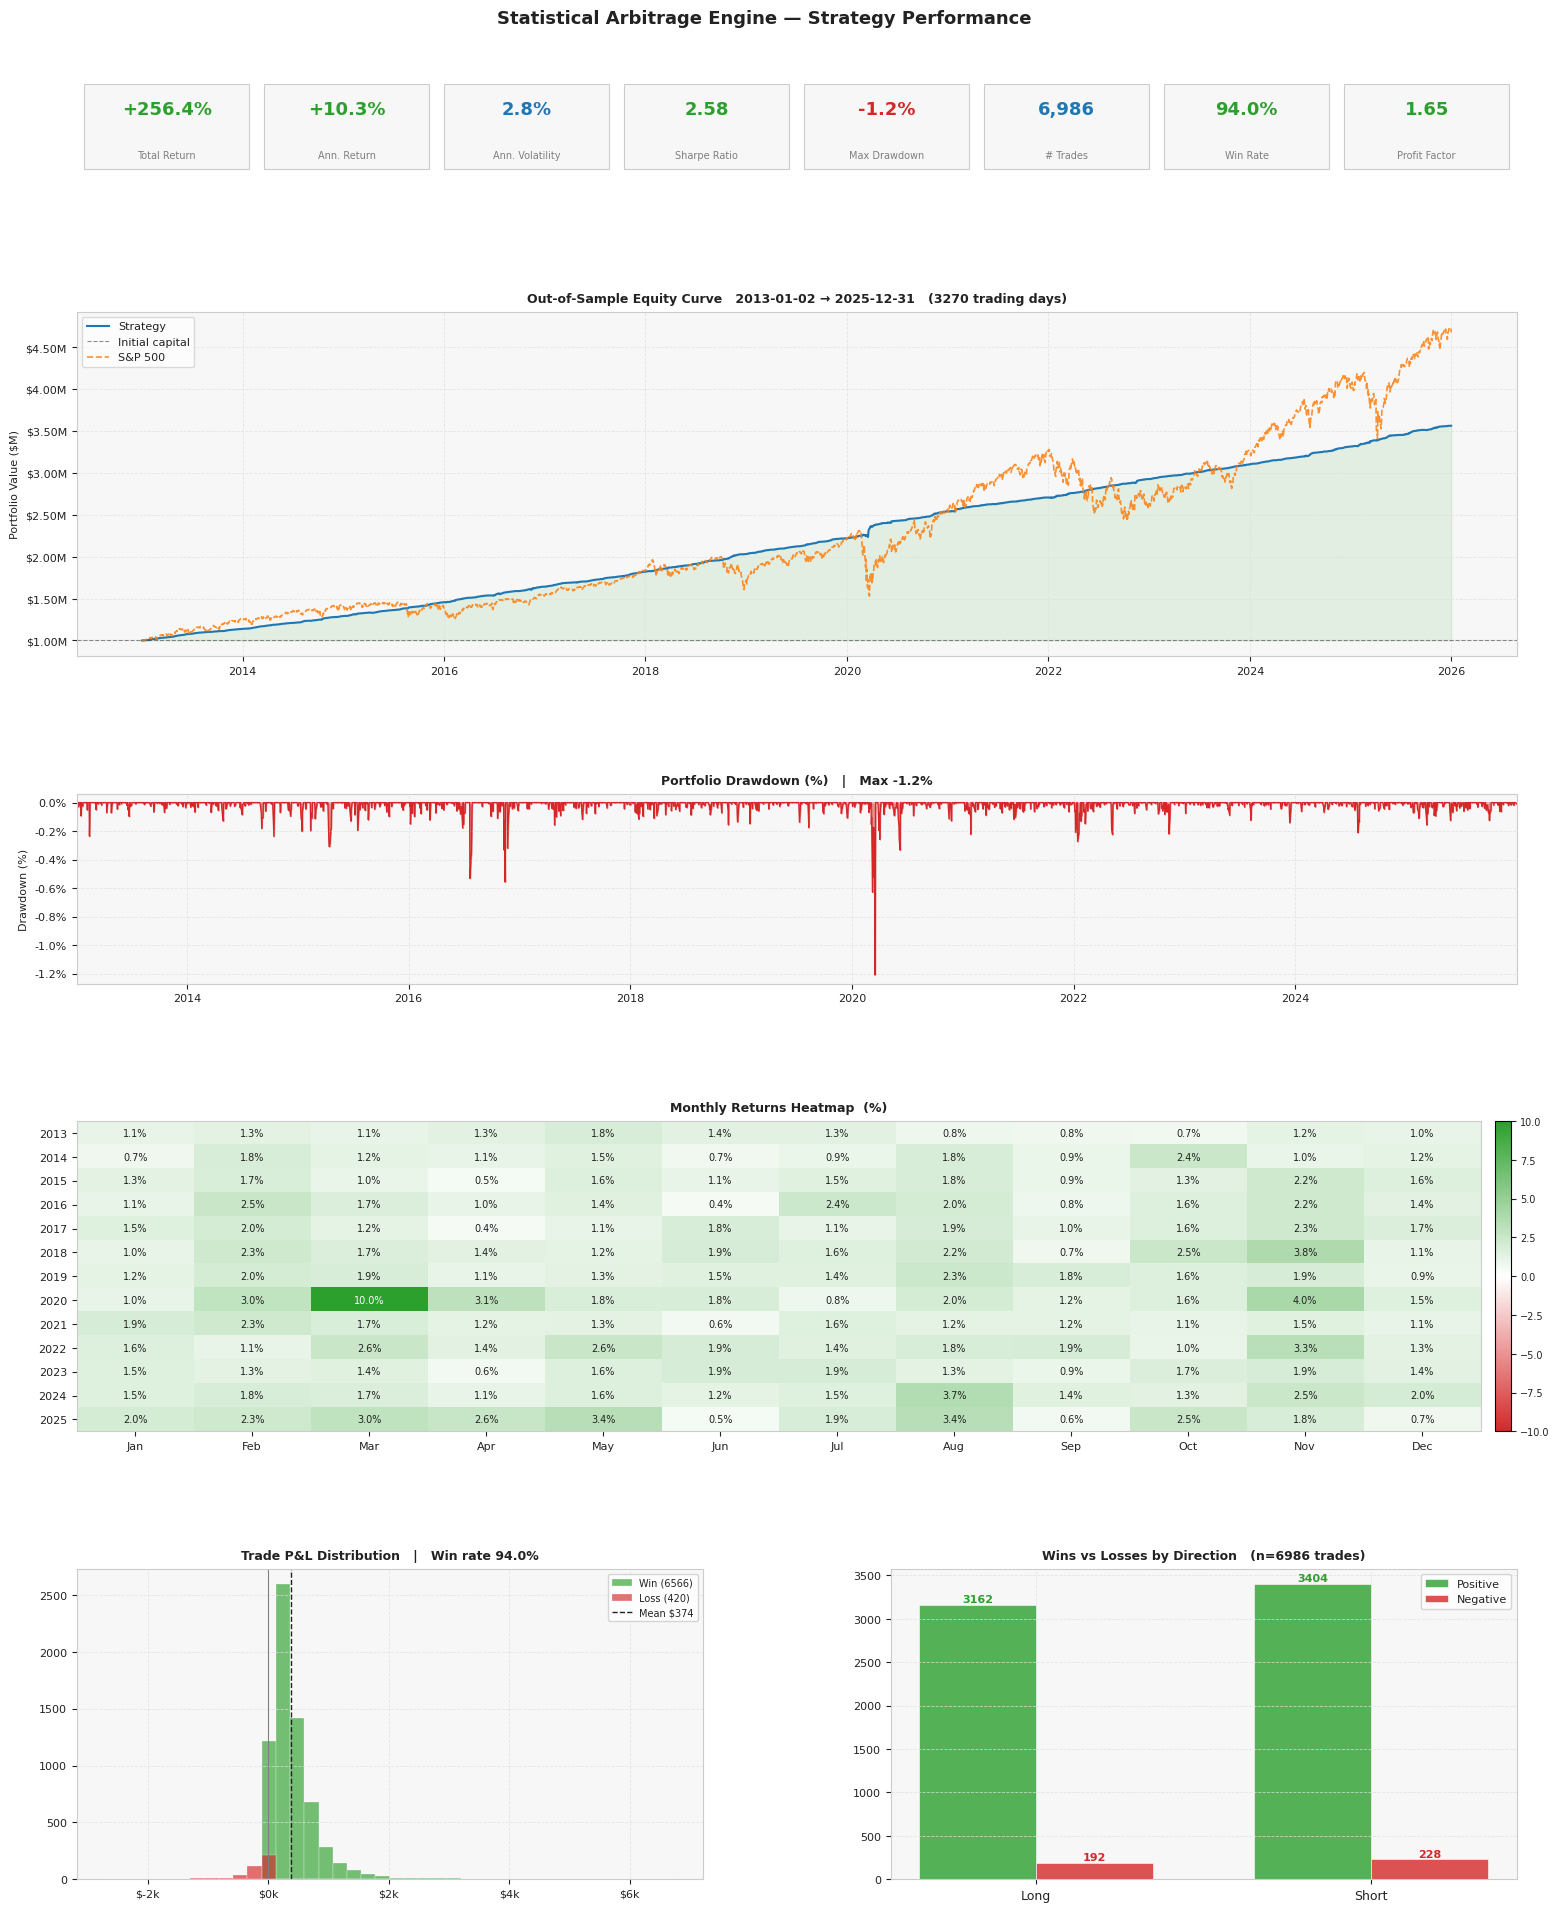

In [29]:
# Run performance dashboard
plot_performance(portfolio_pnl, trade_log)


## ORDER BOOK AND TRADE LEDGER

In [ ]:
from io import BytesIO
import openpyxl
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── Helpers ───────────────────────────────────────────────────────────────────

def _fig_to_buf(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    plt.close(fig)
    return buf

def _style_header(ws, bg="1F4E79", fg="FFFFFF"):
    fill = PatternFill(start_color=bg, end_color=bg, fill_type="solid")
    font = Font(color=fg, bold=True)
    for cell in ws[1]:
        cell.fill = fill
        cell.font = font
        cell.alignment = Alignment(horizontal="center")

def _autowidth(ws, cap=28):
    for col in ws.columns:
        w = max((len(str(c.value or "")) for c in col), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(w + 2, cap)

def _color_pnl_col(ws, col_idx):
    green = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
    red   = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid")
    for row in ws.iter_rows(min_row=2, min_col=col_idx, max_col=col_idx):
        for cell in row:
            try:
                cell.fill = green if float(cell.value) >= 0 else red
            except (TypeError, ValueError):
                pass

def _fmt_currency(ws, col_idx):
    for row in ws.iter_rows(min_row=2, min_col=col_idx, max_col=col_idx):
        for cell in row:
            if cell.value is not None:
                cell.number_format = '#,##0.00'


# ── Capital ledger builder ────────────────────────────────────────────────────

def _build_capital_ledger(trades_df, portfolio_pnl_series, prices_df):
    """
    Explode each trade into two sequential events (ENTRY and EXIT).
    For each event record: prices, share counts, notional values, and a
    running snapshot of portfolio value, capital deployed, and available cash.

    Capital model:
      - Each pair uses capital_per_pair = INITIAL_CAPITAL / n_pairs (equal slice).
      - Long side:  you pay  notional_long  =  CAPITAL_PER_PAIR   (cash OUT)
      - Short side: you receive notional_short = shares_short * short_price (cash IN, held as margin)
      - Net cash at risk per trade = notional_long (short proceeds cover their own margin)
      - total_deployed = sum of notional_long for all currently open trades
      - available_cash  = portfolio_value - total_deployed
    """
    # capital_per_pair stored per trade: INITIAL_CAPITAL / n_pairs that window

    # Pre-build a fast price lookup: prices_df is indexed by date
    def _price(ticker, date):
        if ticker not in prices_df.columns:
            return np.nan
        try:
            # reindex with ffill so holidays/gaps don't return NaN
            return float(prices_df[ticker].reindex(
                [date], method="nearest", tolerance=pd.Timedelta("5D")
            ).iloc[0])
        except Exception:
            return np.nan

    events = []
    for trade_id, row in trades_df.iterrows():
        direction = row["direction"]
        if direction == "Long Spread":
            long_t, short_t = row["ticker_1"], row["ticker_2"]
        else:
            long_t, short_t = row["ticker_2"], row["ticker_1"]

        beta = abs(float(row["entry_kalman_beta"]))   # hedge ratio (always positive)

        # ── Prices at entry ────────────────────────────────────────────────────
        ep_long  = _price(long_t,  row["entry_date"])
        ep_short = _price(short_t, row["entry_date"])

        cap = float(row.get("capital_per_pair", INITIAL_CAPITAL * 0.02))
        sh_long  = cap / ep_long if (not np.isnan(ep_long)  and ep_long  > 0) else np.nan
        sh_short = beta * sh_long          if not np.isnan(sh_long)                      else np.nan

        not_long_entry  = round(cap, 2)
        not_short_entry = round(sh_short * ep_short, 2) \
                          if (not np.isnan(sh_short) and not np.isnan(ep_short)) else None

        events.append({
            "trade_id"         : trade_id,
            "date"             : row["entry_date"],
            "event_type"       : "ENTRY",
            "pair"             : row["pair"],
            "window"           : row["window"],
            "direction"        : direction,
            "long_ticker"      : long_t,
            "short_ticker"     : short_t,
            "long_price"       : round(ep_long,  2) if not np.isnan(ep_long)  else None,
            "short_price"      : round(ep_short, 2) if not np.isnan(ep_short) else None,
            "kalman_beta"      : round(beta, 4),
            "shares_long"      : round(sh_long,  2) if not np.isnan(sh_long)  else None,
            "shares_short"     : round(sh_short, 2) if not np.isnan(sh_short) else None,
            "long_value"       : not_long_entry,           # cash OUT (you bought this)
            "short_value"      : not_short_entry,          # cash IN  (you sold this short)
            "zscore"           : row["entry_zscore"],
            "exit_reason"      : None,
            "trade_pnl"        : None,
            "is_winner"        : None,
            "_cap"             : cap,
            "_short_locked"    : not_short_entry or 0.0,
        })

        # ── Prices at exit ─────────────────────────────────────────────────────
        xp_long  = _price(long_t,  row["exit_date"])
        xp_short = _price(short_t, row["exit_date"])

        not_long_exit  = round(sh_long  * xp_long,  2) \
                         if (not np.isnan(sh_long)  and not np.isnan(xp_long))  else None
        not_short_exit = round(sh_short * xp_short, 2) \
                         if (not np.isnan(sh_short) and not np.isnan(xp_short)) else None

        events.append({
            "trade_id"         : trade_id,
            "date"             : row["exit_date"],
            "event_type"       : "EXIT",
            "pair"             : row["pair"],
            "window"           : row["window"],
            "direction"        : direction,
            "long_ticker"      : long_t,
            "short_ticker"     : short_t,
            "long_price"       : round(xp_long,  2) if not np.isnan(xp_long)  else None,
            "short_price"      : round(xp_short, 2) if not np.isnan(xp_short) else None,
            "kalman_beta"      : round(beta, 4),
            "shares_long"      : round(sh_long,  2) if not np.isnan(sh_long)  else None,
            "shares_short"     : round(sh_short, 2) if not np.isnan(sh_short) else None,
            "long_value"       : not_long_exit,            # what the long is now worth
            "short_value"      : not_short_exit,           # what the short costs to close
            "zscore"           : row["exit_zscore"],
            "exit_reason"      : row["exit_reason"],
            "trade_pnl"        : row["pnl"],
            "is_winner"        : row["pnl"] > 0,
            "_cap"             : cap,
            "_short_locked"    : not_short_entry or 0.0,
        })

    # Sort: chronological; on same date ENTRY before EXIT
    ledger = (pd.DataFrame(events)
               .sort_values(["date", "event_type"], ascending=[True, True])
               .reset_index(drop=True))

    # ── Portfolio mark-to-market value (end of day) ───────────────────────
    cum_pnl = INITIAL_CAPITAL + portfolio_pnl_series.cumsum()
    unique_dates = ledger["date"].unique()
    port_map = {}
    for d in unique_dates:
        try:
            port_map[d] = float(cum_pnl.reindex([d], method="ffill").iloc[0])
        except Exception:
            port_map[d] = np.nan
    ledger["portfolio_value"] = ledger["date"].map(port_map)

    # ── Sequential capital tracking ────────────────────────────────────────
    #
    #  trading_capital:       cash you can deploy right now
    #                         decreases by long_value on ENTRY
    #                         principal (long_value) restored on EXIT only
    #  capital_deployed:      sum of long_values for all open trades
    #  short_proceeds_locked: cash at broker from open short legs (NOT tradeable)
    #  realized_pnl:          cumulative settled P&L — SEPARATE bucket, not redeployed
    #  total_equity:          trading_capital + capital_deployed + realized_pnl

    open_trades          = {}    # tid -> (long_cap, short_locked)
    trading_capital      = float(INITIAL_CAPITAL)
    running_realized_pnl = 0.0

    tc_col      = []
    dep_col     = []
    slocked_col = []
    rpnl_col    = []
    n_open_col  = []

    for _, row in ledger.iterrows():
        tid     = row["trade_id"]
        cap     = float(row["_cap"])
        slocked = float(row["_short_locked"])

        if row["event_type"] == "ENTRY":
            trading_capital -= cap              # cash out for long leg
            open_trades[tid] = (cap, slocked)   # remember original values
        else:
            orig_cap, _ = open_trades.pop(tid, (cap, slocked))
            trading_capital += orig_cap          # principal back (not P&L)
            try:
                running_realized_pnl += float(row["trade_pnl"])  # P&L to separate bucket
            except (TypeError, ValueError):
                pass

        total_deployed = sum(lv for lv, _ in open_trades.values())
        total_slocked  = sum(sv for _, sv in open_trades.values())

        tc_col.append(round(trading_capital, 2))
        dep_col.append(round(total_deployed, 2))
        slocked_col.append(round(total_slocked, 2))
        rpnl_col.append(round(running_realized_pnl, 2))
        n_open_col.append(len(open_trades))

    ledger["trading_capital"]       = tc_col        # free cash for new trades
    ledger["capital_deployed"]      = dep_col        # in open long positions
    ledger["short_proceeds_locked"] = slocked_col    # at broker, informational
    ledger["realized_pnl"]          = rpnl_col       # settled gains (separate)
    ledger["total_equity"]          = (
        ledger["trading_capital"] + ledger["capital_deployed"] + ledger["realized_pnl"]
    )
    ledger["n_open_trades"]         = n_open_col

    ledger = ledger.drop(columns=["trade_id", "is_winner", "_cap", "_short_locked"])
    return ledger


# ── Main export function ──────────────────────────────────────────────────────

def export_analytics(
    portfolio_pnl,
    detailed_trades,
    windows,
    output_path="cache/pairs_analytics.xlsx",
):
    out = Path(output_path)
    trades = detailed_trades.copy()

    if len(trades) == 0:
        print("No trades to export — run the backtest first.")
        return str(out)

    trades["is_winner"]  = trades["pnl"] > 0
    trades["entry_date"] = pd.to_datetime(trades["entry_date"])
    trades["exit_date"]  = pd.to_datetime(trades["exit_date"])

    cum_pnl   = portfolio_pnl.cumsum() + INITIAL_CAPITAL
    dd_series = (cum_pnl - cum_pnl.cummax()) / cum_pnl.cummax() * 100

    # ── Overall metrics ───────────────────────────────────────────────────────
    metrics   = compute_performance(portfolio_pnl)
    best_idx  = trades["pnl"].idxmax()
    worst_idx = trades["pnl"].idxmin()
    extra = {
        "Total Trades"       : len(trades),
        "Winning Trades"     : int(trades["is_winner"].sum()),
        "Losing Trades"      : int((~trades["is_winner"]).sum()),
        "Overall Win Rate"   : f"{trades['is_winner'].mean()*100:.1f}%",
        "Avg Trade P&L"      : f"${trades['pnl'].mean():,.2f}",
        "Median Trade P&L"   : f"${trades['pnl'].median():,.2f}",
        "Best Trade"         : f"${trades['pnl'].max():,.2f}  ({trades.loc[best_idx,'pair']})",
        "Worst Trade"        : f"${trades['pnl'].min():,.2f}  ({trades.loc[worst_idx,'pair']})",
        "Avg Duration (days)": f"{trades['duration_days'].mean():.1f}",
        "Unique Pairs Traded": str(trades["pair"].nunique()),
        "Stop-Loss Exits"    : int((trades["exit_reason"] == "stop_loss").sum()),
        "Z-Reversion Exits"  : int((trades["exit_reason"] == "z_reversion").sum()),
        "Window-End Exits"   : int((trades["exit_reason"] == "window_end").sum()),
    }
    summary_df = pd.DataFrame(
        list(metrics.items()) + [("", "")] + list(extra.items()),
        columns=["Metric", "Value"],
    )

    # ── Per-pair attribution ───────────────────────────────────────────────────
    pair_stats = (
        trades.groupby("pair")
        .agg(
            total_pnl    = ("pnl",           "sum"),
            num_trades   = ("pnl",           "count"),
            winners      = ("is_winner",     "sum"),
            win_rate_raw = ("is_winner",     "mean"),
            avg_pnl      = ("pnl",           "mean"),
            best_trade   = ("pnl",           "max"),
            worst_trade  = ("pnl",           "min"),
            avg_duration = ("duration_days", "mean"),
        )
        .sort_values("total_pnl", ascending=False)
        .reset_index()
    )
    pair_stats.insert(4, "win_rate",
                      (pair_stats["win_rate_raw"] * 100).round(1).astype(str) + "%")
    pair_stats = pair_stats.drop(columns="win_rate_raw")
    for col in ["total_pnl","avg_pnl","best_trade","worst_trade"]:
        pair_stats[col] = pair_stats[col].round(2)
    pair_stats["avg_duration"] = pair_stats["avg_duration"].round(1)

    # ── Daily P&L ─────────────────────────────────────────────────────────────
    daily_df = portfolio_pnl.to_frame("daily_pnl")
    daily_df["cumulative_pnl"]  = portfolio_pnl.cumsum()
    daily_df["portfolio_value"] = INITIAL_CAPITAL + daily_df["cumulative_pnl"]
    daily_df["drawdown_pct"]    = dd_series
    daily_df.index.name = "date"

    # ── Monthly returns pivot ──────────────────────────────────────────────────
    monthly     = portfolio_pnl.resample("ME").sum()
    monthly_tbl = monthly.to_frame("pnl")
    monthly_tbl["year"]  = monthly_tbl.index.year
    monthly_tbl["month"] = monthly_tbl.index.month
    month_pivot = monthly_tbl.pivot(index="year", columns="month", values="pnl")
    month_pivot = month_pivot.reindex(columns=range(1, 13))
    month_pivot.columns   = MONTH_NAMES
    month_pivot["TOTAL"]  = month_pivot.sum(axis=1, skipna=True)
    month_pivot.index.name = "Year"

    # ── Per-window table ───────────────────────────────────────────────────────
    win_rows = []
    for w_idx, (train_end, trade_start, trade_end) in enumerate(windows):
        w_pnl    = portfolio_pnl.loc[trade_start:trade_end]
        w_trades = trades[trades["window"] == w_idx + 1]
        if len(w_pnl) < 5:
            continue
        m = compute_performance(w_pnl)
        win_rows.append({
            "Window"        : w_idx + 1,
            "Trade Start"   : trade_start.date(),
            "Trade End"     : trade_end.date(),
            "Total P&L"     : round(w_pnl.sum(), 2),
            "Num Trades"    : len(w_trades),
            "Win Rate"      : f"{w_trades['is_winner'].mean()*100:.1f}%" if len(w_trades) else "N/A",
            "Ann. Return"   : m["Ann. Return"],
            "Sharpe Ratio"  : m["Sharpe Ratio"],
            "Max Drawdown"  : m["Max Drawdown"],
            "Pairs Active"  : w_trades["pair"].nunique(),
        })
    windows_df = pd.DataFrame(win_rows)

    # ── Capital ledger ─────────────────────────────────────────────────────────
    print("Building capital ledger...")
    ledger = _build_capital_ledger(trades, portfolio_pnl, prices)

    # ── Plots ──────────────────────────────────────────────────────────────────
    plots = {}
    def _safe(key, fn):
        try:
            plots[key] = fn()
        except Exception as e:
            print(f"  Warning: plot '{key}' skipped — {e}")

    def _equity():
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(cum_pnl.index, cum_pnl / 1e6, linewidth=1.3, color="steelblue", label="Strategy")
        ax.axhline(INITIAL_CAPITAL / 1e6, color="black", linestyle="--", linewidth=0.8, label="Initial $1M")
            ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.08, color="red", linewidth=0)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        return _fig_to_buf(fig)
    _safe("equity_curve", _equity)

    def _dd():
        fig, ax = plt.subplots(figsize=(13, 3))
        ax.fill_between(dd_series.index, dd_series, 0, color="crimson", alpha=0.45)
        ax.axhline(-MAX_DRAWDOWN_PCT * 100, color="black", linestyle="--", linewidth=0.9,
                   label=f"Circuit breaker ({-MAX_DRAWDOWN_PCT*100:.0f}%)")
        ax.set_title("Portfolio Drawdown (%)"); ax.set_ylabel("DD %")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        return _fig_to_buf(fig)
    _safe("drawdown", _dd)

    def _pair_bar():
        top_n = min(25, len(pair_stats))
        fig, ax = plt.subplots(figsize=(13, max(4, top_n * 0.36)))
        colors = ["#2ecc71" if v >= 0 else "#e74c3c"
                  for v in pair_stats["total_pnl"].head(top_n)]
        ax.barh(pair_stats["pair"].head(top_n),
                pair_stats["total_pnl"].head(top_n), color=colors, alpha=0.8)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.invert_yaxis(); ax.set_title(f"Per-Pair Total P&L (top {top_n})")
        ax.set_xlabel("P&L ($)"); ax.grid(True, alpha=0.3, axis="x")
        return _fig_to_buf(fig)
    _safe("per_pair_bar", _pair_bar)

    def _dist():
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].hist(trades["pnl"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
        axes[0].axvline(0, color="black", linewidth=1)
        axes[0].axvline(trades["pnl"].mean(), color="red", linestyle="--", linewidth=1,
                        label=f"Mean ${trades['pnl'].mean():,.0f}")
        axes[0].set_title("Trade P&L Distribution"); axes[0].set_xlabel("P&L ($)")
        axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
        wr = trades.groupby("direction")["is_winner"].mean() * 100
        bc = ["#2ecc71" if "Long" in k else "#e74c3c" for k in wr.index]
        axes[1].bar(wr.index, wr.values, color=bc, alpha=0.8)
        axes[1].set_ylim(0, 100); axes[1].set_title("Win Rate by Direction (%)")
        axes[1].set_ylabel("Win Rate (%)"); axes[1].grid(True, alpha=0.3, axis="y")
        for bi, v in enumerate(wr.values):
            axes[1].text(bi, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
        return _fig_to_buf(fig)
    _safe("pnl_distribution", _dist)

    def _dur():
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(trades["duration_days"].clip(upper=130), bins=40,
                color="steelblue", edgecolor="white", alpha=0.8)
        ax.set_title("Trade Duration Distribution")
        ax.set_xlabel("Duration (days, capped 130)"); ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)
        return _fig_to_buf(fig)
    _safe("duration_hist", _dur)

    def _scatter():
        fig, ax = plt.subplots(figsize=(10, 5))
        wm = trades["is_winner"]
        ax.scatter(trades.loc[ wm, "entry_zscore"], trades.loc[ wm, "pnl"],
                   color="#2ecc71", alpha=0.4, s=14, label=f"Winners ({wm.sum()})")
        ax.scatter(trades.loc[~wm, "entry_zscore"], trades.loc[~wm, "pnl"],
                   color="#e74c3c", alpha=0.55, s=14, label=f"Losers ({(~wm).sum()})")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title("Entry Z-Score vs Trade P&L")
        ax.set_xlabel("Entry Z-Score"); ax.set_ylabel("P&L ($)")
        ax.legend(); ax.grid(True, alpha=0.3)
        return _fig_to_buf(fig)
    _safe("zscore_scatter", _scatter)

    def _heatmap():
        _vals  = month_pivot.drop(columns="TOTAL").values.astype(float)
        _valid = _vals[~np.isnan(_vals)]
        vmax   = abs(_valid).max() if len(_valid) else 1
        fig, ax = plt.subplots(figsize=(14, max(3, len(month_pivot) * 0.55)))
        im = ax.imshow(_vals, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_NAMES)
        ax.set_yticks(range(len(month_pivot))); ax.set_yticklabels(month_pivot.index)
        for yi in range(len(month_pivot.index)):
            for xi in range(12):
                v = _vals[yi, xi]
                if not np.isnan(v):
                    ax.text(xi, yi, f"${v/1000:.0f}k", ha="center", va="center",
                            fontsize=7.5,
                            color="black" if abs(v) < vmax * 0.55 else "white")
        plt.colorbar(im, ax=ax, label="P&L ($)")
        ax.set_title("Monthly P&L Heatmap")
        return _fig_to_buf(fig)
    _safe("monthly_heatmap", _heatmap)

    def _sharpe():
        rr = portfolio_pnl / INITIAL_CAPITAL
        rs = rr.rolling(63).mean() / rr.rolling(63).std() * np.sqrt(252)
        fig, ax = plt.subplots(figsize=(13, 3))
        ax.plot(rs.index, rs, linewidth=0.9, color="steelblue")
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axhline(1, color="#2ecc71", linestyle="--", linewidth=0.8, label="Sharpe = 1")
        ax.fill_between(rs.index, rs, 0, where=rs >= 0, alpha=0.2, color="#2ecc71")
        ax.fill_between(rs.index, rs, 0, where=rs <  0, alpha=0.2, color="#e74c3c")
        ax.set_title("Rolling 63-day Sharpe"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        return _fig_to_buf(fig)
    _safe("rolling_sharpe", _sharpe)

    def _exits():
        ec = trades["exit_reason"].value_counts()
        pe = trades.groupby("exit_reason")["pnl"].mean()
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].bar(ec.index, ec.values,
                    color=["#3498db","#2ecc71","#e74c3c"], alpha=0.8)
        axes[0].set_title("Trade Exit Reasons"); axes[0].set_ylabel("Count")
        axes[0].grid(True, alpha=0.3, axis="y")
        bc = ["#2ecc71" if v >= 0 else "#e74c3c" for v in pe.values]
        axes[1].bar(pe.index, pe.values, color=bc, alpha=0.8)
        axes[1].axhline(0, color="black", linewidth=0.8)
        axes[1].set_title("Avg P&L by Exit Reason ($)"); axes[1].grid(True, alpha=0.3, axis="y")
        return _fig_to_buf(fig)
    _safe("exit_reasons", _exits)

    def _top5():
        top5 = pair_stats.head(5)["pair"].tolist()
        fig, ax = plt.subplots(figsize=(13, 5))
        for p in top5:
            pt = trades[trades["pair"] == p].sort_values("entry_date")
            if pt.empty: continue
            ax.plot(pt.set_index("entry_date")["pnl"].cumsum().index,
                    pt.set_index("entry_date")["pnl"].cumsum().values,
                    linewidth=1.2, label=p)
        rest = (trades[~trades["pair"].isin(top5)]
                .groupby("entry_date")["pnl"].sum().cumsum())
        if len(rest):
            ax.plot(rest.index, rest, linewidth=0.9, color="gray",
                    linestyle="--", alpha=0.7, label="All other pairs")
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title("Cumulative Trade P&L — Top 5 Pairs vs Rest")
        ax.set_ylabel("Cumulative P&L ($)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        return _fig_to_buf(fig)
    _safe("top5_cumulative", _top5)

    # ── Write workbook ────────────────────────────────────────────────────────
    ob_cols = ["pair","ticker_1","ticker_2","window","entry_date","exit_date",
               "duration_days","direction","entry_zscore","entry_kalman_beta",
               "entry_kalman_spread","exit_zscore","exit_reason","pnl",
               "is_winner","is_carryover"]

    BLUE_FILL  = PatternFill(start_color="DDEEFF", end_color="DDEEFF", fill_type="solid")
    GREEN_FILL = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
    RED_FILL   = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid")

    CURRENCY_COLS_LEDGER = [
        "long_value","short_value","trade_pnl","portfolio_value",
        "trading_capital","capital_deployed","short_proceeds_locked",
        "realized_pnl","total_equity"
    ]

    with pd.ExcelWriter(out, engine="openpyxl") as writer:

        # ── Tab 1: Summary ─────────────────────────────────────────────────────
        summary_df.to_excel(writer, sheet_name="Summary", index=False, startrow=2)
        ws = writer.sheets["Summary"]
        ws["A1"] = "STATISTICAL ARBITRAGE — PERFORMANCE SUMMARY"
        ws["A1"].font = Font(bold=True, size=13, color="1F4E79")
        _style_header(ws); _autowidth(ws)

        # ── Tab 2: Capital Ledger (the sequential story) ───────────────────────
        ledger.to_excel(writer, sheet_name="Capital_Ledger", index=False)
        ws_cl = writer.sheets["Capital_Ledger"]
        _style_header(ws_cl)

        # Row-level colouring: ENTRY = blue, EXIT winner = green, EXIT loser = red
        ledger_cols = list(ledger.columns)
        et_idx  = ledger_cols.index("event_type")
        pnl_idx = ledger_cols.index("trade_pnl") if "trade_pnl" in ledger_cols else None

        for r_idx, row in enumerate(ws_cl.iter_rows(min_row=2), start=0):
            et = row[et_idx].value
            pv = row[pnl_idx].value if pnl_idx is not None else None
            if et == "ENTRY":
                fill = BLUE_FILL
            elif et == "EXIT":
                try:
                    fill = GREEN_FILL if float(pv) >= 0 else RED_FILL
                except (TypeError, ValueError):
                    fill = PatternFill()
            else:
                fill = PatternFill()
            for cell in row:
                cell.fill = fill

        # Currency format on dollar columns
        for col_name in CURRENCY_COLS_LEDGER:
            if col_name in ledger_cols:
                ci = ledger_cols.index(col_name) + 1
                for cell in ws_cl.iter_rows(min_row=2, min_col=ci, max_col=ci):
                    for c in cell:
                        if c.value is not None:
                            c.number_format = "#,##0.00"

        # Bold the capital-state columns so they stand out
        for col_name in ["trading_capital","capital_deployed","realized_pnl","total_equity","portfolio_value"]:
            if col_name in ledger_cols:
                ci = ledger_cols.index(col_name) + 1
                for cell in ws_cl.iter_rows(min_row=2, min_col=ci, max_col=ci):
                    for c in cell:
                        c.font = Font(bold=True)

        _autowidth(ws_cl, cap=20)

        # ── Tab 3: Order Book ──────────────────────────────────────────────────
        trades[ob_cols].to_excel(writer, sheet_name="Order_Book", index=False)
        ws_ob = writer.sheets["Order_Book"]
        _style_header(ws_ob)
        _color_pnl_col(ws_ob, ob_cols.index("pnl") + 1)
        _autowidth(ws_ob)

        # ── Tab 4: Negative Trades ─────────────────────────────────────────────
        losers = trades[~trades["is_winner"]][ob_cols].sort_values("pnl")
        losers.to_excel(writer, sheet_name="Negative_Trades", index=False)
        ws_neg = writer.sheets["Negative_Trades"]
        _style_header(ws_neg, bg="8B0000")
        _color_pnl_col(ws_neg, ob_cols.index("pnl") + 1)
        _autowidth(ws_neg)

        # ── Tab 5: Per Pair ────────────────────────────────────────────────────
        pair_stats.to_excel(writer, sheet_name="Per_Pair", index=False)
        ws_pp = writer.sheets["Per_Pair"]
        _style_header(ws_pp)
        _color_pnl_col(ws_pp, list(pair_stats.columns).index("total_pnl") + 1)
        _autowidth(ws_pp)

        # ── Tab 6: Daily P&L ───────────────────────────────────────────────────
        daily_df.reset_index().to_excel(writer, sheet_name="Daily_PnL", index=False)
        _style_header(writer.sheets["Daily_PnL"])
        _autowidth(writer.sheets["Daily_PnL"])

        # ── Tab 7: Monthly Returns ─────────────────────────────────────────────
        month_pivot.reset_index().to_excel(writer, sheet_name="Monthly_Returns", index=False)
        ws_mo = writer.sheets["Monthly_Returns"]
        _style_header(ws_mo)
        for row in ws_mo.iter_rows(min_row=2, min_col=2,
                                   max_col=len(month_pivot.columns) + 1):
            for cell in row:
                try:
                    v = float(cell.value)
                    cell.fill = (GREEN_FILL if v >= 0 else RED_FILL)
                    cell.number_format = "#,##0"
                except (TypeError, ValueError):
                    pass
        _autowidth(ws_mo, cap=14)

        # ── Tab 8: Windows ─────────────────────────────────────────────────────
        windows_df.to_excel(writer, sheet_name="Windows", index=False)
        _style_header(writer.sheets["Windows"])
        _autowidth(writer.sheets["Windows"])

        # ── Tab 9: Plots ───────────────────────────────────────────────────────
        ws_plots = writer.book.create_sheet("Plots")
        layout = [
            ("equity_curve",    "B2"),
            ("drawdown",        "B32"),
            ("rolling_sharpe",  "B52"),
            ("per_pair_bar",    "B72"),
            ("pnl_distribution","AC2"),
            ("duration_hist",   "AC30"),
            ("zscore_scatter",  "AC52"),
            ("exit_reasons",    "AC74"),
            ("monthly_heatmap", "B115"),
            ("top5_cumulative", "AC115"),
        ]
        for key, anchor in layout:
            if key in plots:
                try:
                    ws_plots.add_image(XLImage(plots[key]), anchor)
                except Exception as e:
                    print(f"  Warning: could not embed '{key}' — {e}")

    print(f"\nAnalytics workbook saved: {out}")
    print(f"  Tabs: Summary | Capital_Ledger | Order_Book | Negative_Trades | Per_Pair")
    print(f"        Daily_PnL | Monthly_Returns | Windows | Plots")
    print(f"  Capital ledger rows : {len(ledger)} ({len(trades)} trades × 2 events)")
    print(f"  Trades in order book: {len(trades)}")
    print(f"  Unique pairs        : {trades['pair'].nunique()}")
    print(f"  Plots embedded      : {len(plots)}")
    return str(out)


print("export_analytics ready.  Call: export_analytics(portfolio_pnl, trade_log, windows)")


In [25]:
# Run this cell after any backtest to regenerate the analytics workbook
export_analytics(portfolio_pnl, trade_log, windows)

Building capital ledger...

Analytics workbook saved: cache\pairs_analytics.xlsx
  Tabs: Summary | Capital_Ledger | Order_Book | Negative_Trades | Per_Pair
        Daily_PnL | Monthly_Returns | Windows | Plots
  Capital ledger rows : 568 (284 trades × 2 events)
  Trades in order book: 284
  Unique pairs        : 74
  Plots embedded      : 10


'cache\\pairs_analytics.xlsx'